# RobotLoop 数据闭环演示
基于 Ray + MinIO + LanceDB + Zilliz Cloud + Iceberg 的具身智能数据飞轮

In [1]:
import os
import io
import json
import logging
import urllib.parse
from datetime import datetime

import boto3
import requests
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sentence_transformers import SentenceTransformer
from pymilvus import MilvusClient, DataType
import lancedb

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')
logger = logging.getLogger('jupyter-demo')
print('✅ 所有依赖导入成功')

✅ 所有依赖导入成功


## 1. 连接各组件
加载环境变量并初始化 MinIO、Zilliz Cloud、LanceDB、CLIP 模型

In [2]:
# MinIO
S3_ENDPOINT = os.getenv('S3_ENDPOINT', 'http://minio:9000')
S3_ACCESS = os.getenv('S3_ACCESS_KEY', 'minioadmin')
S3_SECRET = os.getenv('S3_SECRET_KEY', 'minioadmin')
S3_BUCKET = 'robotloop-raw'
s3 = boto3.client('s3', endpoint_url=S3_ENDPOINT,
                  aws_access_key_id=S3_ACCESS,
                  aws_secret_access_key=S3_SECRET)

# Zilliz Cloud (Milvus)
MILVUS_URI = os.getenv('MILVUS_URI')
MILVUS_TOKEN = os.getenv('MILVUS_TOKEN')
if not MILVUS_URI or not MILVUS_TOKEN:
    raise ValueError('请设置 MILVUS_URI 和 MILVUS_TOKEN 环境变量')

milvus_client = MilvusClient(uri=MILVUS_URI, token=MILVUS_TOKEN)
COLLECTION_NAME = 'scene_vectors'
if milvus_client.has_collection(COLLECTION_NAME):
    milvus_client.load_collection(COLLECTION_NAME)
    print(f"✅ Zilliz Cloud 集合 '{COLLECTION_NAME}' 已加载")
else:
    print(f"⚠️ 集合 '{COLLECTION_NAME}' 不存在，请先运行 ray-worker")

# LanceDB
LANCE_DB_PATH = os.getenv('LANCE_PATH', '/tmp/lance')
TABLE_NAME = 'robotloop_scenes'
db = lancedb.connect(LANCE_DB_PATH)
if TABLE_NAME in db.table_names():
    table = db.open_table(TABLE_NAME)
    print(f"✅ LanceDB 表 '{TABLE_NAME}' 已打开，行数: {table.count_rows()}")
else:
    table = None
    print('⚠️ LanceDB 表不存在，请先运行 ray-worker')

# 加载 CLIP 模型（从 MinIO 下载）
def load_clip_model(model_name='clip-ViT-B-32', cache_dir='/tmp/models'):
    model_dir = os.path.join(cache_dir, model_name)
    if not os.path.exists(model_dir):
        print(f'⬇️ 从 MinIO 下载 {model_name}...')
        os.makedirs(model_dir, exist_ok=True)
        objects = s3.list_objects_v2(Bucket='models', Prefix=f'{model_name}/')
        if 'Contents' not in objects:
            raise RuntimeError(f'模型 {model_name} 不存在')
        for obj in objects['Contents']:
            key = obj['Key']
            rel_path = key[len(model_name) + 1:]
            target_path = os.path.join(model_dir, rel_path)
            os.makedirs(os.path.dirname(target_path), exist_ok=True)
            s3.download_file('models', key, target_path)
        print(f'✅ 模型下载完成: {model_dir}')
    else:
        print(f'✅ 模型已缓存: {model_dir}')
    return SentenceTransformer(model_dir)

clip_model = load_clip_model()

# 服务端点
MODEL_API = 'http://model-api:9002'
RETRIEVAL_API = 'http://api:8000'
print('\n🚀 所有组件连接成功！')

✅ Zilliz Cloud 集合 'scene_vectors' 已加载
✅ LanceDB 表 'robotloop_scenes' 已打开，行数: 1000
⬇️ 从 MinIO 下载 clip-ViT-B-32...


/tmp/ipykernel_266/3271685240.py:28: DeprecationWarning: table_names() is deprecated, use list_tables() instead
  if TABLE_NAME in db.table_names():
2026-07-19 01:15:46,456 INFO No device provided, using cpu
2026-07-19 01:15:46,457 INFO Loading SentenceTransformer model from /tmp/models/clip-ViT-B-32.


✅ 模型下载完成: /tmp/models/clip-ViT-B-32


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]


🚀 所有组件连接成功！


## 2. 浏览 MinIO 中的原始数据

In [3]:
objects = s3.list_objects_v2(Bucket=S3_BUCKET, Prefix='')
print(f"📦 Bucket '{S3_BUCKET}' 中的文件:")
for obj in objects.get('Contents', [])[:10]:
    key = obj['Key']
    size = obj['Size']
    print(f'  - {key} ({size} bytes)')
if len(objects.get('Contents', [])) > 10:
    print(f'  ... 共 {len(objects["Contents"])} 个文件')

📦 Bucket 'robotloop-raw' 中的文件:
  - raw/demo_pick_red_cube_001.mcap (539295 bytes)
  - scenes/frames/scene_0000_frame_000.png (136177 bytes)
  - scenes/frames/scene_0000_frame_001.png (136177 bytes)
  - scenes/frames/scene_0000_frame_002.png (136177 bytes)
  - scenes/frames/scene_0000_frame_003.png (136177 bytes)
  - scenes/frames/scene_0000_frame_004.png (136177 bytes)
  - scenes/frames/scene_0001_frame_000.png (136177 bytes)
  - scenes/frames/scene_0001_frame_001.png (136177 bytes)
  - scenes/frames/scene_0001_frame_002.png (136177 bytes)
  - scenes/frames/scene_0001_frame_003.png (136177 bytes)
  ... 共 1000 个文件


## 3. 调用模型 API 进行目标检测

🖼️ 处理图像: scenes/frames/scene_0000_frame_000.png


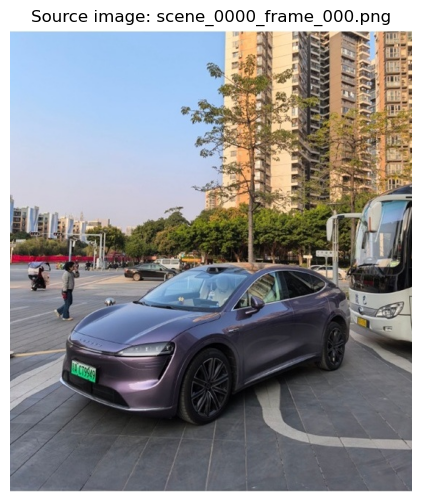


🔍 检测到 8 个物体:
  - car (置信度 1.00)
  - person (置信度 1.00)
  - bus (置信度 0.98)
  - car (置信度 0.84)
  - motorcycle (置信度 0.73)


In [4]:
# 获取第一个图像文件
objects = s3.list_objects_v2(Bucket=S3_BUCKET, Prefix='')
img_key = None
for obj in objects.get('Contents', []):
    if obj['Key'].endswith('.png') or obj['Key'].endswith('.jpg'):
        img_key = obj['Key']
        break

if not img_key:
    print('⚠️ 没有找到图像文件')
else:
    print(f'🖼️ 处理图像: {img_key}')
    try:
        img_obj = s3.get_object(Bucket=S3_BUCKET, Key=img_key)
        img = Image.open(io.BytesIO(img_obj['Body'].read()))
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.title(f"Source image: {img_key.split('/')[-1]}")
        plt.axis('off')
        plt.show()

        # 调用检测 API
        img_obj = s3.get_object(Bucket=S3_BUCKET, Key=img_key)
        files = {'file': (img_key.split('/')[-1], img_obj['Body'].read(), 'image/png')}
        resp = requests.post(f'{MODEL_API}/detect', files=files, timeout=30)
        if resp.status_code == 200:
            detections = resp.json()['detections']
            print(f'\n🔍 检测到 {len(detections)} 个物体:')
            for d in detections[:5]:
                print(f"  - {d['class']} (置信度 {d['confidence']:.2f})")
        else:
            print(f'❌ 检测失败: {resp.status_code}')
    except Exception as e:
        print(f'❌ 错误: {e}')

## 4. 调用模型 API 进行场景标注

In [5]:
scene_id = 'scene_0001'
resp = requests.post(f'{MODEL_API}/annotate', json={'scene_id': scene_id}, timeout=30)
if resp.status_code == 200:
    annot = resp.json()
    print(f"📋 场景 ID: {annot.get('scene_id', 'N/A')}")
    print(f"📝 描述: {annot.get('description', 'N/A')}")
    print(f"⭐ 质量分: {annot.get('quality', 'N/A')}")
    mask_emb = annot.get('mask_emb', [])
    print(f"🔢 Mask Embedding (前5维): {mask_emb[:5] if mask_emb else 'N/A'}...")
else:
    print(f'❌ 标注失败: {resp.status_code}')

📋 场景 ID: scene_0001
📝 描述: a robot navigating a narrow corridor with scattered obstacles
⭐ 质量分: 0.75
🔢 Mask Embedding (前5维): [0.5318232475970683, 0.2693885221248431, 0.09064239004290087, 0.38902751853485074, 0.26265094357153485]...


## 5. 使用检索 API 进行混合搜索

In [6]:
search_params = {
    'text_query': '杂乱厨房，操作台上有碗碟和锅',
    'quality_min': 0.7,
    'scene_type': 'kitchen',
    'top_k': 5
}

print(f"🔍 查询: {search_params['text_query']}")
print(f"📊 条件: scene_type={search_params['scene_type']}, quality_min={search_params['quality_min']}")

# 执行搜索
resp = requests.post(
    f'{RETRIEVAL_API}/search',
    params=search_params,
    timeout=30
)

if resp.status_code == 200:
    results = resp.json()
    print(f"\n✅ 找到 {results['count']} 个匹配场景:")

    for i, r in enumerate(results['results'], 1):
        desc = r.get('scene_description', 'N/A')[:50]
        print(f"  {i}. {r['scene_id']}: {desc}... (质量={r.get('quality_score', 0):.2f})")

    # 打印调试信息
    if 'debug' in results:
        debug = results['debug']
        print(f"\n🔧 调试信息:")
        print(f"  表状态: {debug['table_status']}")
        print(f"  Milvus命中: {debug['milvus_status']}")
        print(f"  LanceDB过滤后: {debug['lancedb_status']}")
else:
    print(f'❌ 检索失败: {resp.status_code} - {resp.text}')

🔍 查询: 杂乱厨房，操作台上有碗碟和锅
📊 条件: scene_type=kitchen, quality_min=0.7

✅ 找到 5 个匹配场景:
  1. scene_0025: a robot navigating a narrow corridor with scattere... (质量=0.71)
  2. scene_0044: a robot navigating a narrow corridor with scattere... (质量=0.95)
  3. scene_0108: a robot navigating a narrow corridor with scattere... (质量=0.86)
  4. scene_0116: a robot navigating a narrow corridor with scattere... (质量=0.74)
  5. scene_0124: a robot navigating a narrow corridor with scattere... (质量=0.99)

🔧 调试信息:
  表状态: initialized, rows=1000
  Milvus命中: success, hits=50
  LanceDB过滤后: success, filtered_count=8


## 6. 直接使用 Zilliz Cloud 进行向量搜索

In [7]:
query_text = '杂乱厨房，操作台上有碗碟和锅'
query_emb = clip_model.encode(query_text).tolist()

print(f"\n查询: '{query_text}'")

results = milvus_client.search(
    collection_name=COLLECTION_NAME,
    data=[query_emb],
    limit=5,
    output_fields=['scene_id']
)

print(f"\n📋 最相似的 5 个场景 (向量距离):")
for i, hit in enumerate(results[0], 1):
    scene_id = hit.get('pk') or hit.get('id') or getattr(hit.entity, 'id', None)
    distance = hit.get('distance', 0.0)
    print(f"  {i}. scene_id={scene_id}, distance={distance:.4f}")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


查询: '杂乱厨房，操作台上有碗碟和锅'

📋 最相似的 5 个场景 (向量距离):
  1. scene_id=scene_0000, distance=0.6521
  2. scene_id=scene_0006, distance=0.6517
  3. scene_id=scene_0008, distance=0.6517
  4. scene_id=scene_0025, distance=0.6517
  5. scene_id=scene_0030, distance=0.6517


## 7. 通过 API 查看数据分布

In [8]:
# 获取统计信息
stats_resp = requests.get(f'{RETRIEVAL_API}/debug/stats', timeout=10)
if stats_resp.status_code == 200:
    stats = stats_resp.json()
    print(f"\n📊 数据统计:")
    print(f"  总行数: {stats.get('total_rows', 'N/A')}")
    print(f"  scene_type 分布: {stats.get('scene_types', {})}")
    print(f"  quality 范围: {stats.get('quality_range', {})}")

# 获取数据样本
data_resp = requests.get(f'{RETRIEVAL_API}/debug/data?limit=3', timeout=10)
if data_resp.status_code == 200:
    data = data_resp.json()
    print(f"\n📋 数据样本 (前3条):")
    for i, row in enumerate(data.get('sample', []), 1):
        desc = row.get('scene_description', 'N/A')[:40]
        print(f"  {i}. {row['scene_id']}: type={row['scene_type']}, quality={row['quality_score']:.2f}")
        print(f"     desc: {desc}...")


📊 数据统计:
  总行数: 1000
  scene_type 分布: {'kitchen': 210, 'lab': 205, 'living_room': 205, 'warehouse': 192, 'corridor': 188}
  quality 范围: {'min': 0.6, 'max': 1.0, 'mean': 0.80062}

📋 数据样本 (前3条):
  1. scene_0000: type=lab, quality=0.66
     desc: foggy morning in a construction site...
  2. scene_0001: type=warehouse, quality=0.65
     desc: rainy street with reflections on the gro...
  3. scene_0002: type=living_room, quality=0.66
     desc: rainy street with reflections on the gro...


## 8. 闭环总结

1. **数据采集**：设备端生成模拟数据 → 上传至 MinIO → Kafka 事件触发。
2. **数据处理**：Ray Worker 消费 Kafka，执行标注、向量化、写入 LanceDB/Zilliz Cloud/Iceberg。
3. **混合检索**：通过语义向量 + 结构化过滤，快速定位高价值训练数据。
4. **数据飞轮**：检索结果可作为训练数据索引，模型迭代后新数据再次入湖。